In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import cv2
from decimer_segmentation import segment_chemical_structures

In [6]:
PROJECT_DIR = Path.cwd().parent

RENDERED_DIR = PROJECT_DIR / "data" / "rendered_pages"
SEGMENTED_DIR = PROJECT_DIR / "data" / "segmented_structures"
METADATA_DIR = PROJECT_DIR / "data" / "metadata"

print(RENDERED_DIR)
print(SEGMENTED_DIR)

d:\Projects\DECIMER Project\data\rendered_pages
d:\Projects\DECIMER Project\data\segmented_structures


In [7]:
page_images = sorted(RENDERED_DIR.rglob("*.png"))
print(f"Total rendered pages: {len(page_images)}")
page_images[:5]

Total rendered pages: 21


[WindowsPath('d:/Projects/DECIMER Project/data/rendered_pages/sample_pdf_1/sample_pdf_1_page_001.png'),
 WindowsPath('d:/Projects/DECIMER Project/data/rendered_pages/sample_pdf_1/sample_pdf_1_page_002.png'),
 WindowsPath('d:/Projects/DECIMER Project/data/rendered_pages/sample_pdf_1/sample_pdf_1_page_003.png'),
 WindowsPath('d:/Projects/DECIMER Project/data/rendered_pages/sample_pdf_1/sample_pdf_1_page_004.png'),
 WindowsPath('d:/Projects/DECIMER Project/data/rendered_pages/sample_pdf_1/sample_pdf_1_page_005.png')]

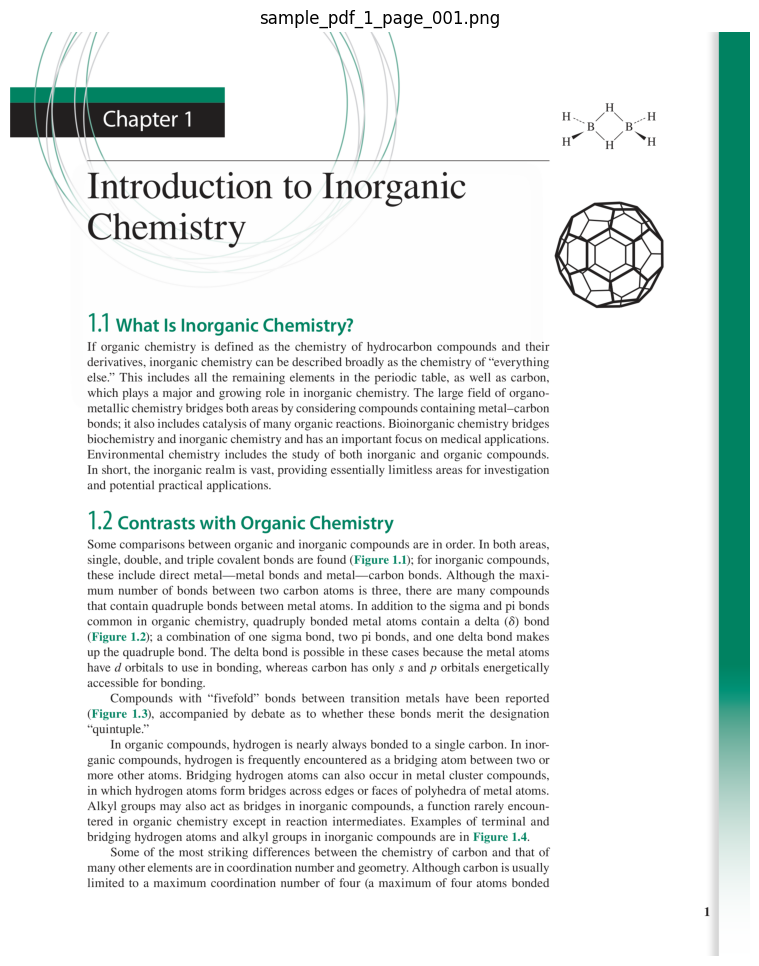

In [8]:
sample = page_images[0]

img = Image.open(sample)

plt.figure(figsize=(10,12))
plt.imshow(img)
plt.axis("off")
plt.title(sample.name);

In [9]:
image = cv2.imread(str(sample))

structures = segment_chemical_structures(image)
print(f"Detected structures: {len(structures)}")

Detected structures: 1


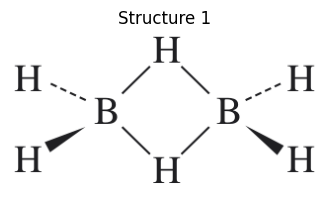

In [10]:
for i, structure in enumerate(structures):
    
    plt.figure(figsize=(4,4))
    plt.imshow(structure)
    plt.axis("off")
    plt.title(f"Structure {i+1}")
    plt.show()

In [11]:
paper_name = sample.parent.name

output_folder = SEGMENTED_DIR / paper_name
output_folder.mkdir(exist_ok=True)

records = []

for idx, structure in enumerate(structures):
    filename = f"{sample.stem}_structure_{idx+1:03d}.png"
    save_path = output_folder / filename
    Image.fromarray(structure).save(save_path)
    
    records.append({
        "pdf_name": paper_name,
        "page": sample.stem,
        "structure_id": idx+1,
        "image_path": str(save_path),
        "width": structure.shape[1],
        "height": structure.shape[0]
    })

metadata = pd.DataFrame(records)
metadata

,pdf_name,page,structure_id,image_path,width,height
0,sample_pdf_1,sample_pdf_1_page_001,1,d:\Projects\DECIMER Project\data\segmented_str...,314,159


In [12]:
from PIL import Image
import cv2
from tqdm import tqdm

all_records = []

for page in tqdm(page_images):

    paper_name = page.parent.name

    output_folder = SEGMENTED_DIR / paper_name
    output_folder.mkdir(parents=True, exist_ok=True)

    try:
        # Read page image
        image = cv2.imread(str(page))

        # Run DECIMER Segmentation
        structures = segment_chemical_structures(image)

        # Save each detected structure
        for idx, structure in enumerate(structures):

            filename = f"{page.stem}_structure_{idx+1:03d}.png"
            save_path = output_folder / filename

            # Convert NumPy array to PIL Image and save
            Image.fromarray(structure).save(save_path)

            all_records.append({
                "pdf_name": paper_name,
                "page": page.stem,
                "structure_id": idx + 1,
                "image_path": str(save_path),
                "width": structure.shape[1],
                "height": structure.shape[0]
            })

    except Exception as e:
        print(f"\n❌ Failed on {page.name}")
        print(e)

# Create metadata DataFrame
segmentation_df = pd.DataFrame(all_records)

print(f"\nTotal structures extracted: {len(segmentation_df)}")

segmentation_df.head()

100%|██████████| 21/21 [03:26<00:00,  9.82s/it]


Total structures extracted: 123


,pdf_name,page,structure_id,image_path,width,height
0,sample_pdf_1,sample_pdf_1_page_001,1,d:\Projects\DECIMER Project\data\segmented_str...,314,159
1,sample_pdf_1,sample_pdf_1_page_002,1,d:\Projects\DECIMER Project\data\segmented_str...,224,161
2,sample_pdf_1,sample_pdf_1_page_002,2,d:\Projects\DECIMER Project\data\segmented_str...,238,222
3,sample_pdf_1,sample_pdf_1_page_002,3,d:\Projects\DECIMER Project\data\segmented_str...,515,396
4,sample_pdf_1,sample_pdf_1_page_002,4,d:\Projects\DECIMER Project\data\segmented_str...,197,145


In [19]:
segmentation_df = pd.DataFrame(all_records)
print(segmentation_df.shape)
segmentation_df.head()

(123, 6)


,pdf_name,page,structure_id,image_path,width,height
0,sample_pdf_1,sample_pdf_1_page_001,1,d:\Projects\DECIMER Project\data\segmented_str...,314,159
1,sample_pdf_1,sample_pdf_1_page_002,1,d:\Projects\DECIMER Project\data\segmented_str...,224,161
2,sample_pdf_1,sample_pdf_1_page_002,2,d:\Projects\DECIMER Project\data\segmented_str...,238,222
3,sample_pdf_1,sample_pdf_1_page_002,3,d:\Projects\DECIMER Project\data\segmented_str...,515,396
4,sample_pdf_1,sample_pdf_1_page_002,4,d:\Projects\DECIMER Project\data\segmented_str...,197,145


In [20]:
csv_path = METADATA_DIR / "segmentation_results.csv"
segmentation_df.to_csv(csv_path, index=False)
print(csv_path)

d:\Projects\DECIMER Project\data\metadata\segmentation_results.csv


In [21]:
print(f"Total Pages       : {segmentation_df['page'].nunique()}")
print(f"Total Structures  : {len(segmentation_df)}")
print(f"Unique PDFs       : {segmentation_df['pdf_name'].nunique()}")

Total Pages       : 18
Total Structures  : 123
Unique PDFs       : 3
